## Homework

> Note: sometimes your answer doesn't match one of 
> the options exactly. That's fine. 
> Select the option that's closest to your solution.
> If it's exactly in between two options, select the higher value.


### Dataset

In this homework, we continue using the fuel efficiency dataset.
Download it from <a href='https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv'>here</a>.

You can do it with wget:

```bash
wget https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv
```

The goal of this homework is to create a regression model for predicting the car fuel efficiency (column `'fuel_efficiency_mpg'`).



### Preparing the dataset 

Preparation:

* Fill missing values with zeros.
* Do train/validation/test split with 60%/20%/20% distribution. 
* Use the `train_test_split` function and set the `random_state` parameter to 1.
* Use `DictVectorizer(sparse=True)` to turn the dataframes into matrices.

In [103]:
data = "https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv"

In [104]:
# !wget $data -O "../data/car_fuel_efficiency.csv"

In [105]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer

import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline


In [106]:
df = pd.read_csv("../data/car_fuel_efficiency.csv")
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


In [107]:
df.isnull().sum()

engine_displacement      0
num_cylinders          482
horsepower             708
vehicle_weight           0
acceleration           930
model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors              502
fuel_efficiency_mpg      0
dtype: int64

In [108]:
df.dtypes

engine_displacement      int64
num_cylinders          float64
horsepower             float64
vehicle_weight         float64
acceleration           float64
model_year               int64
origin                  object
fuel_type               object
drivetrain              object
num_doors              float64
fuel_efficiency_mpg    float64
dtype: object

In [109]:
numeric_columns = list(df.select_dtypes(include=['int64', 'float64']).columns)
numeric_columns

['engine_displacement',
 'num_cylinders',
 'horsepower',
 'vehicle_weight',
 'acceleration',
 'model_year',
 'num_doors',
 'fuel_efficiency_mpg']

In [110]:
categorical_columns = list(df.select_dtypes(include=['object']).columns)
categorical_columns

['origin', 'fuel_type', 'drivetrain']

In [111]:
for col in numeric_columns:
    df[col] = df[col].fillna(0.0)

In [112]:
df.isnull().sum()

engine_displacement    0
num_cylinders          0
horsepower             0
vehicle_weight         0
acceleration           0
model_year             0
origin                 0
fuel_type              0
drivetrain             0
num_doors              0
fuel_efficiency_mpg    0
dtype: int64

In [113]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

print('Training set size:', len(df_train), f"{len(df_train) / (len(df_train) + len(df_val) + len(df_test))}")
print('Validation set size:', len(df_val), f"{len(df_val) / (len(df_train) + len(df_val) + len(df_test))}")
print('Test set size:', len(df_test), f"{len(df_test) / (len(df_train) + len(df_val) + len(df_test))}")

Training set size: 5822 0.5999587798845837
Validation set size: 1941 0.20002061005770816
Test set size: 1941 0.20002061005770816


In [114]:
df_train_dicts = df_train.to_dict(orient='records')
df_val_dicts = df_val.to_dict(orient='records')
df_test_dicts = df_test.to_dict(orient='records')

In [115]:
dv = DictVectorizer(sparse=True)
X_train = dv.fit_transform(df_train_dicts)
X_val = dv.transform(df_val_dicts)
X_test = dv.transform(df_test_dicts)

## Question 1

Let's train a decision tree regressor to predict the `fuel_efficiency_mpg` variable. 

* Train a model with `max_depth=1`.


Which feature is used for splitting the data?


* **`'vehicle_weight'`**
* `'model_year'`
* `'origin'`
* `'fuel_type'`

In [116]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(max_depth=1, random_state=1)
dt.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=1, random_state=1)

In [117]:
feature_index = dt.tree_.feature[0]
feature_index

np.int64(13)

In [118]:
split_feature = dv.feature_names_[feature_index]
print("Q1 Split feature:", split_feature)

Q1 Split feature: vehicle_weight


In [119]:
from sklearn.tree import export_text

In [120]:
print(export_text(dt, feature_names=dv.get_feature_names_out()))

|--- vehicle_weight <= 3022.11
|   |--- value: [16.88]
|--- vehicle_weight >  3022.11
|   |--- value: [12.94]



## Question 2

Train a random forest regressor with these parameters:

* `n_estimators=10`
* `random_state=1`
* `n_jobs=-1` (optional - to make training faster)


What's the RMSE of this model on the validation data?

* 0.045
* **0.45**
* 4.5
* 45.0

In [121]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [122]:
rf = RandomForestRegressor(n_estimators=10, random_state=1, n_jobs=-1)
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=10, n_jobs=-1, random_state=1)

In [123]:
y_pred = rf.predict(X_val)
y_pred

array([18.6542484 , 15.26730256, 18.09860353, ..., 14.83453826,
       13.47299213, 16.19681562], shape=(1941,))

In [124]:
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print("Q2 RMSE:", rmse)

Q2 RMSE: 0.45866154584849067


## Question 3

Now let's experiment with the `n_estimators` parameter

* Try different values of this parameter from 10 to 200 with step 10.
* Set `random_state` to `1`.
* Evaluate the model on the validation dataset.


After which value of `n_estimators` does RMSE stop improving?
Consider 3 decimal places for calculating the answer.

- 10
- 25
- 80
- **200**

If it doesn't stop improving, use the latest iteration number in
your answer.

In [125]:
scores = []

for n in range(10, 201, 10):
    rf = RandomForestRegressor(n_estimators=n, random_state=1, n_jobs=-1)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    scores.append((n, rmse))

for n, s in scores:
    print(n, s)

10 0.45866154584849067
20 0.45367991021440807
30 0.45117160299870146
40 0.44835735902806817
50 0.44617922938257604
60 0.44529984913635234
70 0.4446744627744229
80 0.44499364294473354
90 0.44520450225183406
100 0.4448958321700875
110 0.4437175613239899
120 0.4441005815461587
130 0.4437729440618521
140 0.44350150667748467
150 0.4430200410161778
160 0.44278873172443844
170 0.4428940618484624
180 0.44254812253330855
190 0.4426065346594649
200 0.44251983445804555


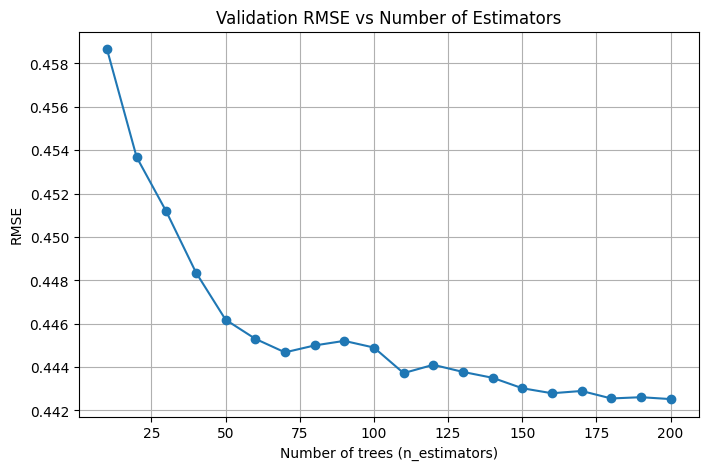

In [126]:
n_values = [n for n, _ in scores]
rmse_values = [rmse for _, rmse in scores]

plt.figure(figsize=(8, 5))
plt.plot(n_values, rmse_values, marker='o')
plt.title("Validation RMSE vs Number of Estimators")
plt.xlabel("Number of trees (n_estimators)")
plt.ylabel("RMSE")
plt.grid(True)
plt.show()

## Question 4

Let's select the best `max_depth`:

* Try different values of `max_depth`: `[10, 15, 20, 25]`
* For each of these values,
  * try different values of `n_estimators` from 10 till 200 (with step 10)
  * calculate the mean RMSE 
* Fix the random seed: `random_state=1`


What's the best `max_depth`, using the mean RMSE?

* **10**
* 15
* 20
* 25

In [127]:
depths = [10, 15, 20, 25]
results = {}

for d in depths:
    rmse_list = []
    for n in range(10, 201, 10):
        rf = RandomForestRegressor(max_depth=d, n_estimators=n, random_state=1, n_jobs=-1)
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        rmse_list.append(rmse)
    results[d] = np.mean(rmse_list)

In [128]:
results

{10: np.float64(0.44187929925252156),
 15: np.float64(0.44561628816456206),
 20: np.float64(0.4456793443309614),
 25: np.float64(0.4457024986347514)}

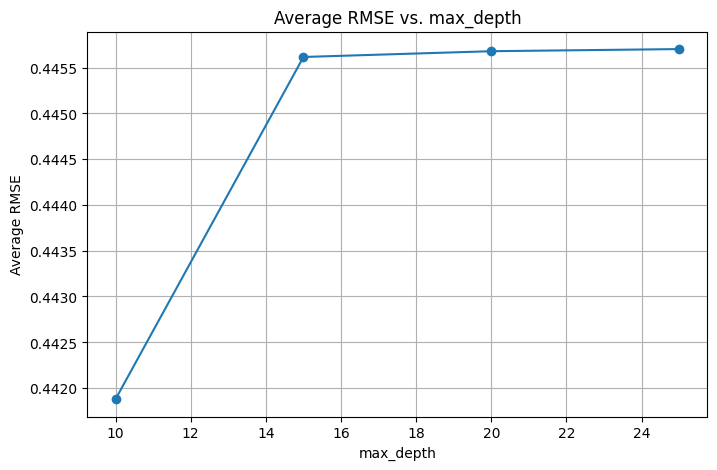

In [129]:
plt.figure(figsize=(8, 5))
plt.plot(results.keys(), results.values(), marker='o')
plt.title("Average RMSE vs. max_depth")
plt.xlabel("max_depth")
plt.ylabel("Average RMSE")
plt.grid(True)
plt.show()

# Question 5

We can extract feature importance information from tree-based models. 

At each step of the decision tree learning algorithm, it finds the best split. 
When doing it, we can calculate "gain" - the reduction in impurity before and after the split. 
This gain is quite useful in understanding what are the important features for tree-based models.

In Scikit-Learn, tree-based models contain this information in the
[`feature_importances_`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html#sklearn.ensemble.RandomForestRegressor.feature_importances_)
field. 

For this homework question, we'll find the most important feature:

* Train the model with these parameters:
  * `n_estimators=10`,
  * `max_depth=20`,
  * `random_state=1`,
  * `n_jobs=-1` (optional)
* Get the feature importance information from this model


What's the most important feature (among these 4)? 

* **`vehicle_weight`**
*	`horsepower`
* `acceleration`
* `engine_displacement`	

In [130]:
rf = RandomForestRegressor(
    n_estimators=10, 
    max_depth=20, 
    random_state=1, 
    n_jobs=-1
)
rf.fit(X_train, y_train)

importances = rf.feature_importances_
feat_imp = sorted(zip(dv.feature_names_, importances), key=lambda x: -x[1])
for name, imp in feat_imp[:10]:
    print(f"{name}: {imp:.4f}")

vehicle_weight: 0.9592
horsepower: 0.0161
acceleration: 0.0115
engine_displacement: 0.0033
model_year: 0.0032
num_cylinders: 0.0023
num_doors: 0.0016
origin=USA: 0.0005
origin=Europe: 0.0005
origin=Asia: 0.0005


## Question 6

Now let's train an XGBoost model! For this question, we'll tune the `eta` parameter:

* Install XGBoost
* Create DMatrix for train and validation
* Create a watchlist
* Train a model with these parameters for 100 rounds:

```
xgb_params = {
    'eta': 0.3, 
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'reg:squarederror',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1,
}
```

Now change `eta` from `0.3` to `0.1`.

Which eta leads to the best RMSE score on the validation dataset?

* 0.3
* **0.1**
* Both give equal value

In [131]:
import xgboost as xgb

In [132]:
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)
watchlist = [(dtrain, 'train'), (dval, 'val')]

In [133]:
xgb_params = {
    'eta': 0.3,
    'max_depth': 6,
    'min_child_weight': 1,
    'objective': 'reg:squarederror',
    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}

model_03 = xgb.train(
    xgb_params, dtrain, 
    num_boost_round=100, 
    evals=watchlist, 
    early_stopping_rounds=10
)

[0]	train-rmse:1.81393	val-rmse:1.85444
[1]	train-rmse:1.31919	val-rmse:1.35353
[2]	train-rmse:0.98120	val-rmse:1.01316
[3]	train-rmse:0.75443	val-rmse:0.78667
[4]	train-rmse:0.60680	val-rmse:0.64318
[5]	train-rmse:0.51381	val-rmse:0.55664
[6]	train-rmse:0.45470	val-rmse:0.50321
[7]	train-rmse:0.41881	val-rmse:0.47254
[8]	train-rmse:0.39534	val-rmse:0.45509
[9]	train-rmse:0.38038	val-rmse:0.44564
[10]	train-rmse:0.37115	val-rmse:0.43896
[11]	train-rmse:0.36361	val-rmse:0.43594
[12]	train-rmse:0.35850	val-rmse:0.43558
[13]	train-rmse:0.35365	val-rmse:0.43394
[14]	train-rmse:0.35025	val-rmse:0.43349
[15]	train-rmse:0.34666	val-rmse:0.43362
[16]	train-rmse:0.34459	val-rmse:0.43378
[17]	train-rmse:0.34128	val-rmse:0.43405
[18]	train-rmse:0.33822	val-rmse:0.43391
[19]	train-rmse:0.33709	val-rmse:0.43374
[20]	train-rmse:0.33553	val-rmse:0.43376
[21]	train-rmse:0.33243	val-rmse:0.43453
[22]	train-rmse:0.33031	val-rmse:0.43510
[23]	train-rmse:0.32815	val-rmse:0.43601


In [134]:
xgb_params['eta'] = 0.1
model_01 = xgb.train(
    xgb_params, 
    dtrain, 
    num_boost_round=100, 
    evals=watchlist, 
    early_stopping_rounds=10
)

[0]	train-rmse:2.28944	val-rmse:2.34561
[1]	train-rmse:2.07396	val-rmse:2.12434
[2]	train-rmse:1.88066	val-rmse:1.92597
[3]	train-rmse:1.70730	val-rmse:1.74987
[4]	train-rmse:1.55163	val-rmse:1.59059
[5]	train-rmse:1.41247	val-rmse:1.44988
[6]	train-rmse:1.28796	val-rmse:1.32329
[7]	train-rmse:1.17660	val-rmse:1.20930
[8]	train-rmse:1.07736	val-rmse:1.10830
[9]	train-rmse:0.98883	val-rmse:1.02009
[10]	train-rmse:0.91008	val-rmse:0.94062
[11]	train-rmse:0.84030	val-rmse:0.87100
[12]	train-rmse:0.77874	val-rmse:0.80916
[13]	train-rmse:0.72417	val-rmse:0.75465
[14]	train-rmse:0.67626	val-rmse:0.70780
[15]	train-rmse:0.63402	val-rmse:0.66672
[16]	train-rmse:0.59690	val-rmse:0.63062
[17]	train-rmse:0.56447	val-rmse:0.60016
[18]	train-rmse:0.53619	val-rmse:0.57383
[19]	train-rmse:0.51138	val-rmse:0.55044
[20]	train-rmse:0.48983	val-rmse:0.53064
[21]	train-rmse:0.47135	val-rmse:0.51451
[22]	train-rmse:0.45501	val-rmse:0.49998
[23]	train-rmse:0.44120	val-rmse:0.48790
[24]	train-rmse:0.42929	va

In [135]:
y_pred_03 = model_03.predict(dval)
y_pred_03

array([18.659534, 15.309505, 18.18359 , ..., 14.35945 , 13.554421,
       15.68892 ], shape=(1941,), dtype=float32)

In [136]:
y_pred_01 = model_01.predict(dval)
y_pred_01

array([18.598583, 15.21174 , 18.314535, ..., 14.614651, 13.501518,
       15.729582], shape=(1941,), dtype=float32)

In [137]:
rmse_03 = np.sqrt(mean_squared_error(y_val, y_pred_03))
rmse_01 = np.sqrt(mean_squared_error(y_val, y_pred_01))

print(f"RMSE (eta=0.3): {rmse_03:.4f}")
print(f"RMSE (eta=0.1): {rmse_01:.4f}")

RMSE (eta=0.3): 0.4359
RMSE (eta=0.1): 0.4252
